# 01 — Keşifsel Veri Analizi (EDA)

Bu notebook, kredi kartı dolandırıcılığı veri setini modelleme öncesi anlamak için hazırlanmıştır.

## Bu notebookun amacı

- Veri yapısını hızlıca doğrulamak (satır/sütun, tipler, eksik değer)
- Hedef değişkenin (`Class`) dengesizliğini ölçmek
- `Amount` ve `Time` gibi ana değişkenlerin dağılımını incelemek
- Hedef değişken ile temel ilişkileri görmek (korelasyon)

## Beklenen çıktı

Bu analiz sonunda şu sorulara net cevap verebiliyor olacağız:

1. Veri temiz mi, eksik değer var mı?
2. Sınıf dengesizliği ne kadar ciddi?
3. Hangi değişkenler hedefle daha ilişkili görünüyor?
4. Baseline model için hangi ön işleme adımları gerekli olabilir?

In [13]:
import sys
from pathlib import Path

# Proje kökü: notebooks/ -> bir üst dizin
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from fraud_detection.paths import DEFAULT_DATA_PATH

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 1) Veriyi yükleme ve ilk kontrol

Bu bölümde veri dosyasının gerçekten mevcut olduğunu doğruluyor ve DataFrame'i belleğe alıyoruz.

- Dosya yoksa `assert` ile erken hata verip süreci durdururuz.
- `shape` ve `head()` ile temel yapıyı hızlıca görürüz.

Not: Veri dosyası yolu `src/fraud_detection/paths.py` içindeki `DEFAULT_DATA_PATH` üzerinden gelir.

In [14]:
assert DEFAULT_DATA_PATH.exists(), f"Veri bulunamadı: {DEFAULT_DATA_PATH} — data/README.md talimatlarına bakın."

df = pd.read_csv(DEFAULT_DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2) Şema ve veri kalitesi

Önce veri tiplerini ve null durumunu kontrol ediyoruz.

- `df.info()` sütun tiplerini, toplam satır sayısını ve null durumunu verir.
- Eksik değer analizi, modelleme öncesi temizleme ihtiyacını gösterir.

Yorumlama:
- Eğer eksik değer yoksa bu veri setinde imputasyon adımı zorunlu olmayabilir.
- Uygun olmayan tip varsa (ör. sayısal olması gereken object), dönüşüm gerekir.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

## 3) Hedef değişken analizi (`Class`)

Bu veri seti tipik olarak **aşırı dengesiz**dir. Önce bunu nicel olarak görüyoruz.

- Sınıf adetleri (`value_counts`) veri dengesini gösterir.
- Yüzde dağılımı, dengesizliğin ciddiyetini daha anlaşılır hale getirir.

Yorumlama:
- Fraud oranı çok düşükse, doğruluk (accuracy) tek başına yanıltıcı olur.
- İleride `precision`, `recall`, `PR-AUC` gibi metriklere odaklanmak gerekir.

In [17]:
class_counts = df["Class"].value_counts().sort_index()
class_ratio = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class counts:\n", class_counts)
print("\nClass ratio (%):\n", class_ratio.round(4))

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class ratio (%):
 Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


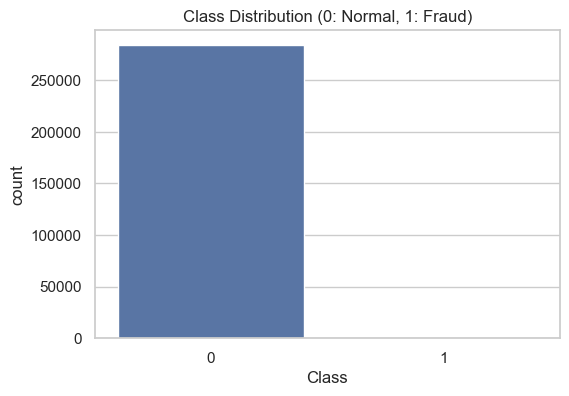

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0: Normal, 1: Fraud)")
plt.show()

## 4) `Amount` ve `Time` dağılım analizi

Bu bölümde işlem tutarı ve zaman değişkenini inceliyoruz.

- `Amount` genelde sağa çarpık olur; bu yüzden `log1p` dönüşümü eklenir.
- `Time` dağılımı veri toplama penceresi hakkında fikir verir.
- `Class` bazında `Amount` kutu grafiği, sınıflar arası farkı görselleştirir.

Yorumlama:
- Güçlü çarpıklık varsa ölçekleme/dönüşüm model performansına katkı sağlar.
- Sınıflar arası ayrım zayıfsa tek değişkenle ayrıştırma zor olabilir; çok değişkenli model gerekir.

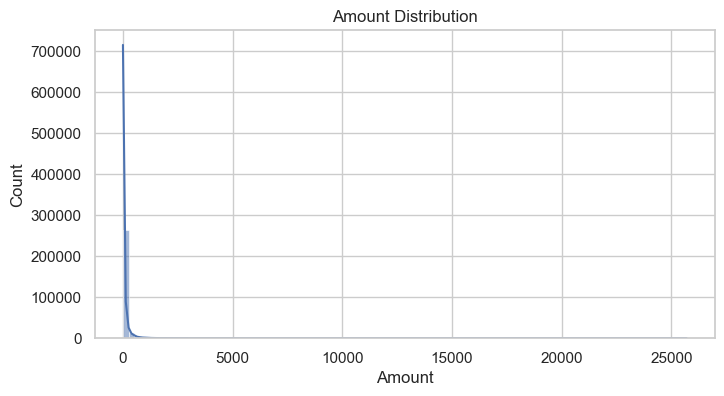

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Amount"], bins=100, kde=True)
plt.title("Amount Distribution")
plt.show()

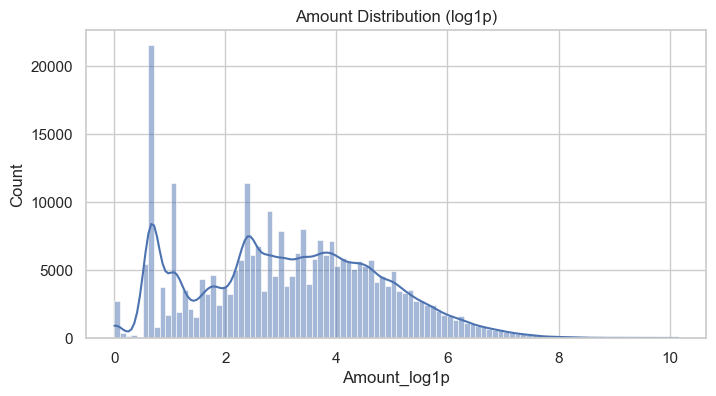

In [20]:
df["Amount_log1p"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 4))
sns.histplot(df["Amount_log1p"], bins=100, kde=True)
plt.title("Amount Distribution (log1p)")
plt.show()

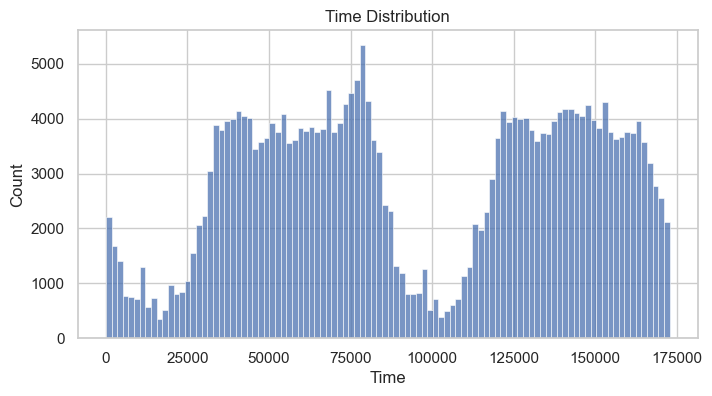

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Time"], bins=100, kde=False)
plt.title("Time Distribution")
plt.show()

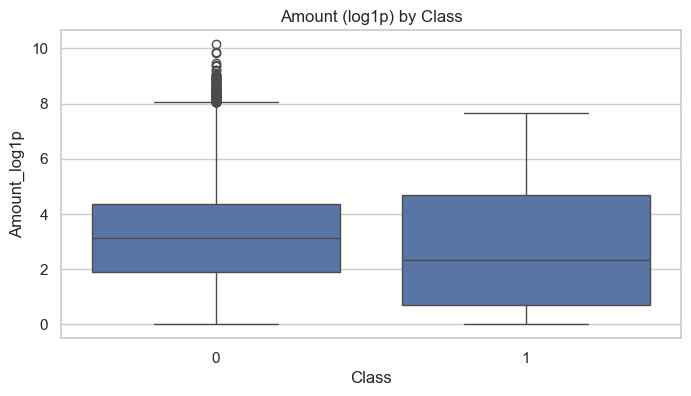

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Class", y="Amount_log1p", data=df)
plt.title("Amount (log1p) by Class")
plt.show()

## 5) İstatistiksel özet ve hedefle ilişki

Son bölümde:

- `describe()` ile temel istatistikleri özetliyoruz.
- `Class` ile korelasyon sıralaması çıkararak ilk sinyal aldığımız değişkenleri görüyoruz.

Yorumlama:
- Korelasyon nedensellik değildir; yalnızca ilk yönlendirme verir.
- Modelleme aşamasında çapraz doğrulama ile gerçek katkı test edilmelidir.

In [23]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [24]:
corr_with_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)

print("Top positive correlations with Class:")
print(corr_with_target.head(10))
print("\nTop negative correlations with Class:")
print(corr_with_target.tail(10))

Top positive correlations with Class:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top negative correlations with Class:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


Veri boyutu: 284,807 satır, 32 sütun.
Eksik değer durumu: Toplam eksik değer sayısı 0.
Fraud oranı: %0.1727 (Class=1).
Dikkat çeken örüntüler: Amount değişkeni sağa çarpık; log1p dönüşümü sonrası dağılım daha dengeli görünüyor.
Class ile en yüksek pozitif ilişki: V11 (0.1549), en yüksek negatif ilişki: V17 (-0.3265).
Sonraki adım (M2): Stratified train/test split + baseline Logistic Regression + ROC-AUC ve PR metrikleri.
